# Import Necessary Libralies

In [137]:
# Math thingy
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# K-mean Algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Read the data file

In [138]:
def read_file(filepath):
    """reads the data file and shows as a dataframe."""
    df = pd.read_csv(filepath)
    return df

In [139]:
iris = 'iris.data'
df = read_file(iris)
df.sample(8)

,5.1,3.5,1.4,0.2,Iris-setosa
79,5.5,2.4,3.8,1.1,Iris-versicolor
139,6.7,3.1,5.6,2.4,Iris-virginica
58,5.2,2.7,3.9,1.4,Iris-versicolor
63,5.6,2.9,3.6,1.3,Iris-versicolor
101,7.1,3.0,5.9,2.1,Iris-virginica
18,5.1,3.8,1.5,0.3,Iris-setosa
55,6.3,3.3,4.7,1.6,Iris-versicolor
99,6.3,3.3,6.0,2.5,Iris-virginica


# Get the overview of the dataset

In [140]:
df.columns

Index(['5.1', '3.5', '1.4', '0.2', 'Iris-setosa'], dtype='object')

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [142]:
df.shape

(149, 5)

In [143]:
df.isnull().sum().sum()

0

In [144]:
df.duplicated().sum()

3

# Data Cleaning

In [ ]:
def preprocessing(filepath):
    """cleans the dataset."""

    mapper = {
        0: "sepal_length",
        1: "sepal_width",
        2: "petal_length",
        3: "petal_width",
        4: "species"
    }

    # Read the data file and ADD header=None
    df = pd.read_csv(filepath, header=None)
    
    # drop duplicated rows 
    df = df.drop_duplicates()
    
    # Reset the index after dropping rows
    df = df.reset_index(drop=True) # drop=True prevents the old index from becoming a new column

    # Rename the columns
    df = df.rename(columns=mapper)

    return df

In [146]:
df_iris = preprocessing(iris)
df_iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
30,4.8,3.1,1.6,0.2,Iris-setosa
70,5.9,3.2,4.8,1.8,Iris-versicolor
93,5.0,2.3,3.3,1.0,Iris-versicolor
11,4.8,3.4,1.6,0.2,Iris-setosa
129,7.2,3.0,5.8,1.6,Iris-virginica


# K-means Algoritmh

## Data Preparation 
- Standardize the data

In [ ]:
# 1. Select only the numerical features for clustering
X = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# 2. Standardize the data (Correctly using StandardScaler)
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

# 3. Initialize PCA to keep 3 principal components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled) # X_pca is the final feature set

# Convert the PCA result back to a DataFrame for convenience
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])

# Print the explained variance ratio to see how much information is retained
# This shows how much of the original data's variability is captured by PC1 and PC2 PC3
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Total Variance Explained by 3 Components: {explained_variance:.4f}") # Should be 0.9935

Total Variance Explained by 3 Components: 0.9947


## Identify Optimal Numbers of Cluster
- Using the elbow method

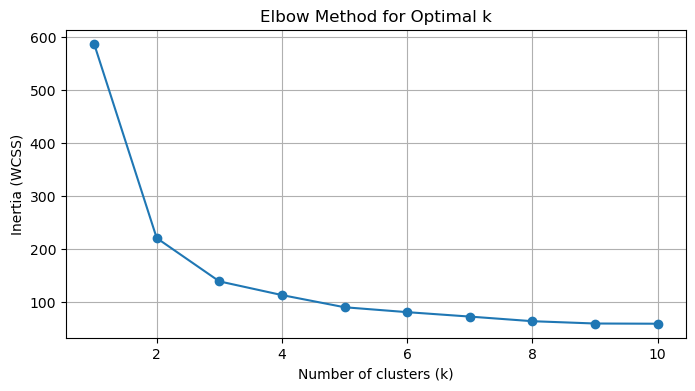

In [148]:
def optimise_k_means(data, max_k):
    """Identifies the optimal numbers of cluster."""
    
    # Corrected variable name: 'ks' instead of 'mean' for clarity
    ks = []
    inertias = []

    # Iterate from k=1 up to (but not including) max_k
    for k in range(1, max_k):
        # 1. K-means model creation and fitting
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(data)

        # 2. Append results (k, and the inertia)
        ks.append(k)
        inertias.append(kmeans.inertia_)
        
    # Generate the elbow plot
    fig = plt.subplots(figsize=(8, 4))
    plt.plot(ks, inertias, 'o-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia (WCSS)')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()


# We'll use max_k=11 to test k=1 through k=10
optimise_k_means(X_scaled, max_k=11)

# Applying K-means Clustering
- random_state=42: This ensures that anyone (or you, later) running the code will get the exact same cluster assignments every single time, making your analysis reproducible.
- n_init='auto' ; By running multiple times from different starting points, we maximize the chance of finding the globally optimal clustering solution, making the result more reliable and robust.

In [ ]:
# Initialize the model with the optimal k=3
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init='auto')

# Fit the model using the PCA-transformed data (X_pca)
kmeans_pca.fit(X_pca)

# Get the cluster labels
cluster_labels_pca = kmeans_pca.labels_

# Add the new cluster labels to the original DataFrame
df_iris['Cluster_PCA'] = cluster_labels_pca

# Plot the results

## Prepare data for the plotting

In [150]:
X_unscaled = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] 

# FIX: Change 'Cluster' to 'Cluster_PCA'
y_cluster = df_iris['Cluster_PCA']

## Visualise the plot

- You need to access the kmeans.cluster_centers_ and plot those points separately.
- Crucial Note: The kmeans.cluster_centers_ contains the coordinates of the centroids in SCALED space. To plot them alongside your UNSCALED data, we need to inverse transform the centroids back to the original scale.

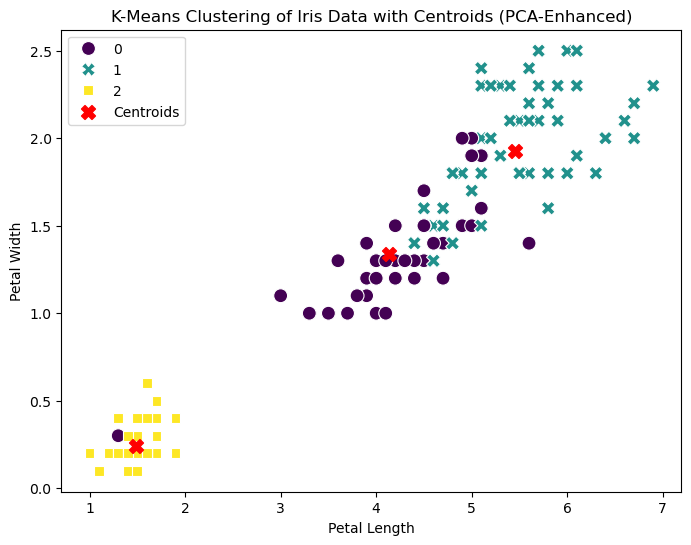

In [151]:
# 1. Get the SCALED centroid coordinates (in PCA space)
centroids_scaled = kmeans_pca.cluster_centers_

# 2. Inverse PCA Transformation - FIX THE VARIABLE NAME
# This transforms the 2 PCA features back into 4 SCALED original features
# You should use 'centroids_scaled' here
centroids_scaled_features = pca.inverse_transform(centroids_scaled)

# 3. Inverse Scaling Transformation
# This transforms the 4 SCALED features back into 4 UNSCALED original features
centroids_unscaled = scaler.inverse_transform(centroids_scaled_features)

# 4. Convert the unscaled centroids back to a DataFrame for easier plotting
# This uses the 4 unscaled features
centroids_df = pd.DataFrame(centroids_unscaled, columns=X.columns)

# Plotting Code with Centroids
plt.figure(figsize=(8, 6))

# Scatter Plot for Data Points - FIX HUE AND STYLE
sns.scatterplot(
    x=df_iris['petal_length'], 
    y=df_iris['petal_width'], 
    hue=df_iris['Cluster_PCA'], # FIX: Use Cluster_PCA
    palette='viridis', 
    style=df_iris['Cluster_PCA'], # FIX: Use Cluster_PCA
    s=100, 
    legend='full'
)

# Add Centroids (This block was already correct for unscaled features)
plt.scatter(
    x=centroids_df['petal_length'], 
    y=centroids_df['petal_width'], 
    marker='X',                     
    s=100, # Increased size for visibility                      
    color='red',                    
    label='Centroids'
)

plt.title('K-Means Clustering of Iris Data with Centroids (PCA-Enhanced)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

# Interpretation

In [152]:
# FIX: Change 'Cluster' to 'Cluster_PCA'
cluster_analysis_pca = df_iris.groupby('Cluster_PCA').mean(numeric_only=True)

print("Cluster Means (PCA-Enhanced):")
print(cluster_analysis_pca)

Cluster Means (PCA-Enhanced):
             sepal_length  sepal_width  petal_length  petal_width
Cluster_PCA                                                      
0                5.702222     2.633333      4.195556     1.320000
1                6.696364     3.060000      5.418182     1.938182
2                5.021277     3.455319      1.465957     0.248936


# Model Evaluation

In [153]:
# True labels remain the same
species_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y_true = df_iris['species'].map(species_mapping) # True labels as numbers

# FIX: Change y_pred to use the 'Cluster_PCA' column
y_pred_pca = df_iris['Cluster_PCA']  # Predicted K-means cluster labels from PCA model

# Calculate the Adjusted Rand Index
ari_score_pca = adjusted_rand_score(y_true, y_pred_pca)

print(f"NEW Adjusted Rand Index (ARI) Score (with PCA): {ari_score_pca:.4f}")
print("\nNEW Confusion Matrix (True vs. Predicted Clusters with PCA):")
print(confusion_matrix(y_true, y_pred_pca))

NEW Adjusted Rand Index (ARI) Score (with PCA): 0.6479

NEW Confusion Matrix (True vs. Predicted Clusters with PCA):
[[ 1  0 47]
 [37 13  0]
 [ 7 42  0]]
